<a href="https://colab.research.google.com/github/indra1236/indra/blob/main/Pengolahan_citra_digital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pilih dan Unggah Gambar untuk Memulai Proses...


Saving 09b91c5d3d238c1097325be8bd927cd7.jpg to 09b91c5d3d238c1097325be8bd927cd7 (4).jpg
-> Gambar '09b91c5d3d238c1097325be8bd927cd7 (4).jpg' berhasil dimuat (736x1308 piksel).

HASIL PEMROSESAN CITRA



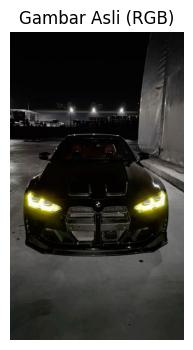

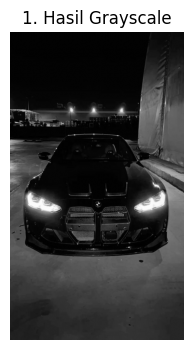

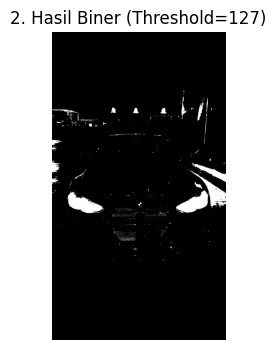

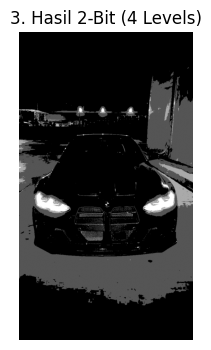

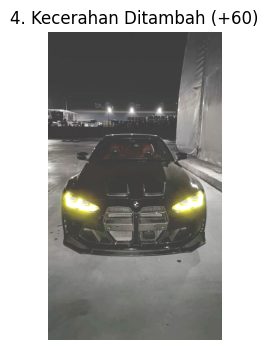

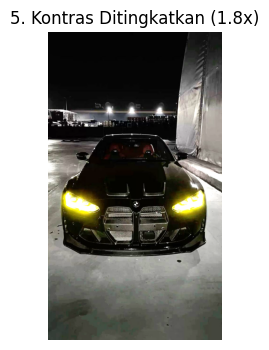

/tmp/ipykernel_10803/1521624878.py:69: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.ravel(), 256, [0, 256], color='black')


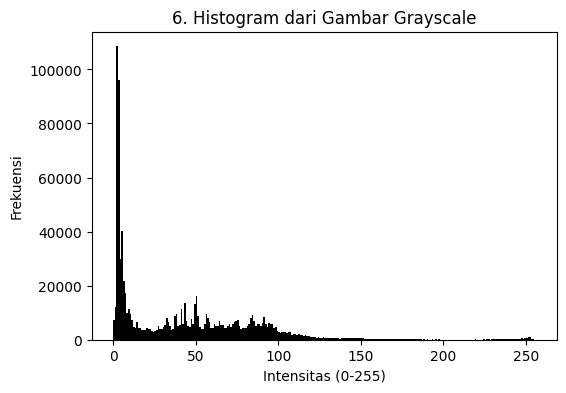

/tmp/ipykernel_10803/1521624878.py:122: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(1, 2, 2); plt.title(" Histogram Setelah Equalization"); plt.hist(img_equalized.ravel(), 256, [0, 256], color='black')


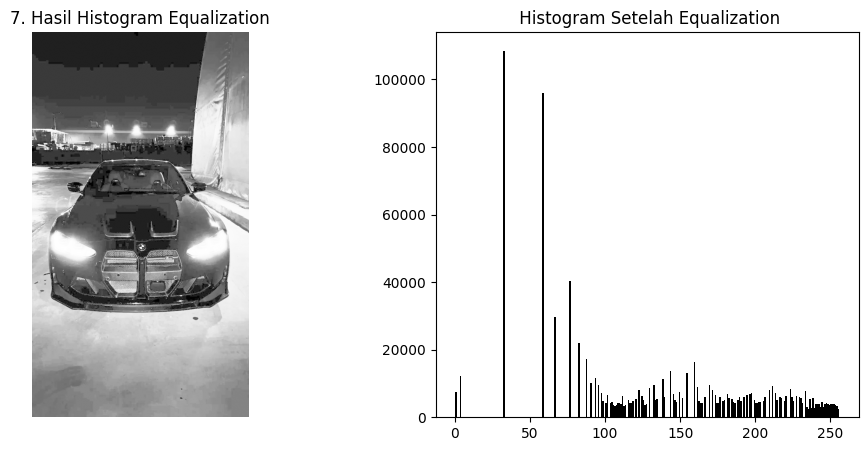

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import files
import io

# ==========================================
# BAGIAN I: Unggah Gambar (Interaktif)
# ==========================================
print("Pilih dan Unggah Gambar untuk Memulai Proses...")
uploaded = files.upload()

# Mengambil file pertama yang diunggah
for fn in uploaded.keys():
  # Membaca data gambar dari memori
  file_bytes = np.frombuffer(uploaded[fn], np.uint8)
  # Decode ke format BGR (standar OpenCV)
  img_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

  # Konversi BGR ke RGB agar warna tampil benar di Matplotlib
  img_original_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  print(f"-> Gambar '{fn}' berhasil dimuat ({img_bgr.shape[1]}x{img_bgr.shape[0]} piksel).")
  break # Kita hanya memproses satu gambar pertama

# ==========================================
# BAGIAN II: Definisikan Fungsi-fungsi Proses
# ==========================================

# 1. Konversi RGB ke Grayscale
def convert_to_grayscale(img_rgb):
    # Rumus: Y = 0.299*R + 0.587*G + 0.114*B
    gray_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return gray_img

# 2. Konversi Grayscale ke Biner
def convert_to_binary(gray_img, threshold_val=127):
    # Piksel > threshold_val jadi Putih (255), sisanya Hitam (0)
    _, binary_img = cv2.threshold(gray_img, threshold_val, 255, cv2.THRESH_BINARY)
    return binary_img, threshold_val

# 3. Konversi Grayscale ke M-Bit (Quantization)
def convert_to_mbit(gray_img, bits=2):
    levels = 2**bits
    # Menghitung interval: setiap level keabuan baru mewakili berapa nilai asli
    interval = 256 / levels
    # Kuantisasi: Membagi piksel, membulatkan, lalu mengembalikan ke skala 0-255
    mbit_img = (np.floor(gray_img / interval) * (255 / (levels - 1))).astype(np.uint8)
    return mbit_img, bits

# 4 & 5. Brightness & Contrast Adjustment
def adjust_bright_contrast(img_rgb, brightness=0, contrast=1.0):
    # Output = Contrast * Input + Brightness
    # cv2.convertScaleAbs menangani saturasi otomatis (clipping 0-255)
    adjusted_img = cv2.convertScaleAbs(img_rgb, alpha=contrast, beta=brightness)
    return adjusted_img

# 7. Operasi Histogram Equalization
def apply_histogram_equalization(gray_img):
    # Meratakan distribusi intensitas piksel (global contrast enhancement)
    equalized_img = cv2.equalizeHist(gray_img)
    return equalized_img

# Fungsi Bantu untuk Menampilkan Gambar di Colab
def show_result(image, title, cmap_type=None, is_histogram=False):
    plt.figure(figsize=(6, 4))
    if is_histogram:
        plt.title(title)
        # Menghitung dan memplot histogram (0-255)
        plt.hist(image.ravel(), 256, [0, 256], color='black')
        plt.xlabel('Intensitas (0-255)')
        plt.ylabel('Frekuensi')
    else:
        plt.title(title)
        if cmap_type:
            plt.imshow(image, cmap=cmap_type)
        else:
            plt.imshow(image)
        plt.axis('off')
    plt.show()

# ==========================================
# BAGIAN III: Eksekusi dan Visualisasi
# ==========================================

if 'img_bgr' in locals():
    print("\n" + "="*40)
    print("HASIL PEMROSESAN CITRA")
    print("="*40 + "\n")

    # 0. Menampilkan Gambar Asli
    show_result(img_original_rgb, "Gambar Asli (RGB)")

    # 1. RGB ke Grayscale
    img_gray = convert_to_grayscale(img_original_rgb)
    show_result(img_gray, "1. Hasil Grayscale", cmap_type='gray')

    # 2. Grayscale ke Biner
    img_binary, t_val = convert_to_binary(img_gray)
    show_result(img_binary, f"2. Hasil Biner (Threshold={t_val})", cmap_type='gray')

    # 3. Grayscale ke M-Bit (Contoh: 2-bit / 4 warna)
    img_mbit, b_val = convert_to_mbit(img_gray, bits=2)
    show_result(img_mbit, f"3. Hasil {b_val}-Bit (4 Levels)", cmap_type='gray')

    # 4. Image Brightness (Contoh: +60 / Lebih Terang)
    img_bright = adjust_bright_contrast(img_original_rgb, brightness=60, contrast=1.0)
    show_result(img_bright, "4. Kecerahan Ditambah (+60)")

    # 5. Image Contrast (Contoh: Contrast 1.8 / Lebih Tajam)
    img_contrast = adjust_bright_contrast(img_original_rgb, brightness=0, contrast=1.8)
    show_result(img_contrast, "5. Kontras Ditingkatkan (1.8x)")

    # 6. Grayscale to Histogram
    show_result(img_gray, "6. Histogram dari Gambar Grayscale", is_histogram=True)

    # 7. Operasi Histogram Equalization
    img_equalized = apply_histogram_equalization(img_gray)

    # Menampilkan perbandingan Equalization
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1); plt.title("7. Hasil Histogram Equalization"); plt.imshow(img_equalized, cmap='gray'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.title(" Histogram Setelah Equalization"); plt.hist(img_equalized.ravel(), 256, [0, 256], color='black')
    plt.show()

else:
    print("Gagal memulai. Silakan unggah gambar terlebih dahulu.")

Gonzalez, R. C., & Woods, R. E. (2018). Digital Image Processing (4th Edition). Pearson.